# Hierarchical clustering

In this notebook, we will look at Hierarchical clustering, more specific **Agglomerative clustering**. First, let us import the relevant modules and dataset.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import AgglomerativeClustering

In [2]:
data = pd.read_csv("Ch5_age_income_data.csv")
X = data[['age', 'income']]

Note that Agglomerative clustering is also based on a distance measure, so we need to scale the data here as well.

In [3]:
minMaxScaler = MinMaxScaler()
X_scaled_mm = pd.DataFrame(minMaxScaler.fit_transform(X), columns=X.columns)

We build the agglomerative clustering model the same as the K-Means model. Note that we **do** specify a number of clusters. This is to get some actual cluster assignments.

In [4]:
aggClustering = AgglomerativeClustering(n_clusters=3)
aggClustering.fit(X_scaled_mm)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",3
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


We can also get the cluster assignments the same way:

In [5]:
data["3aggCluster"] = aggClustering.labels_
data["3aggCluster"]

0       0
1       1
2       2
3       1
4       0
       ..
8100    0
8101    0
8102    2
8103    2
8104    0
Name: 3aggCluster, Length: 8105, dtype: int64

Note, however, that we do not have centroids for Agglomerative clustering, so we do not need to plot them. Let us visualise the Agglomerative clustering for 3 clusters:

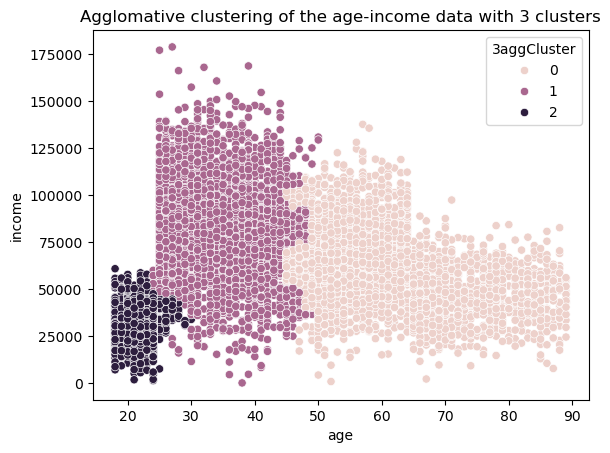

In [6]:
sns.scatterplot(data = data, x = "age", y = "income", hue = "3aggCluster")
plt.title("Agglomative clustering of the age-income data with 3 clusters")
plt.show()

Let us now try to visualize different choices of number of clusters for Agglomerative clustering, in a "bottom-up away". We first build a function that takes an `n` and plot the agglomerative clustering for `n` clusters

In [7]:
def aggClustering(n):
    agg = AgglomerativeClustering(n_clusters=n)
    agg.fit(X_scaled_mm)

    data["aggCluster{0}".format(n)] = agg.labels_

    plt.figure(figsize=(8, 6))

    sns.scatterplot(data = data, x = "age", y = "income", hue = "aggCluster{0}".format(n), palette="deep")
    plt.title("Agglomative clustering of the age-income data with {0} clusters".format(n))
    plt.show()

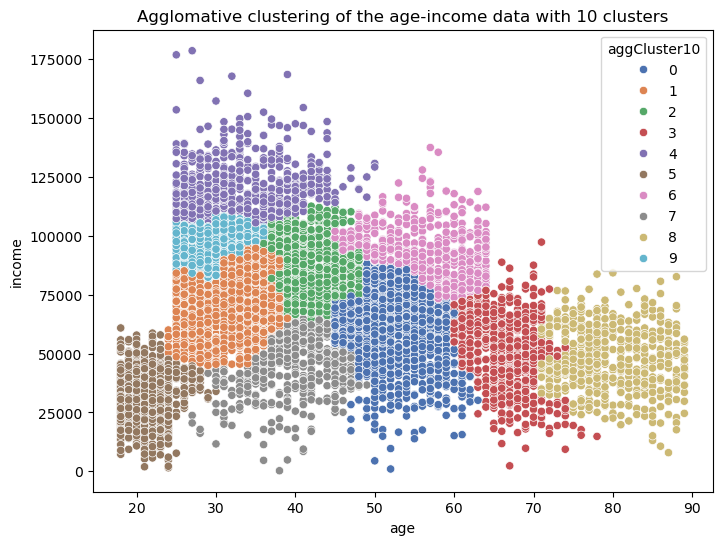

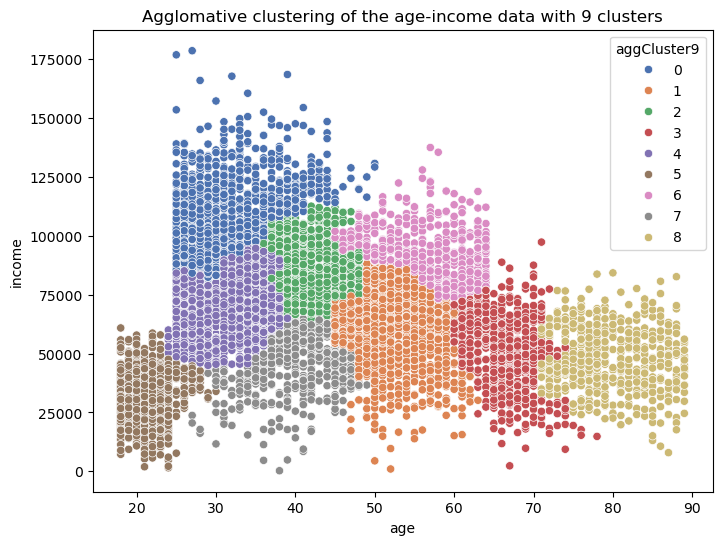

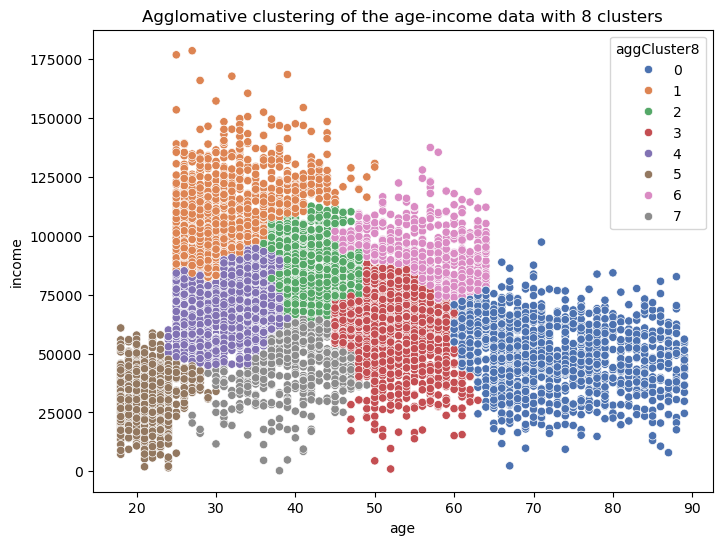

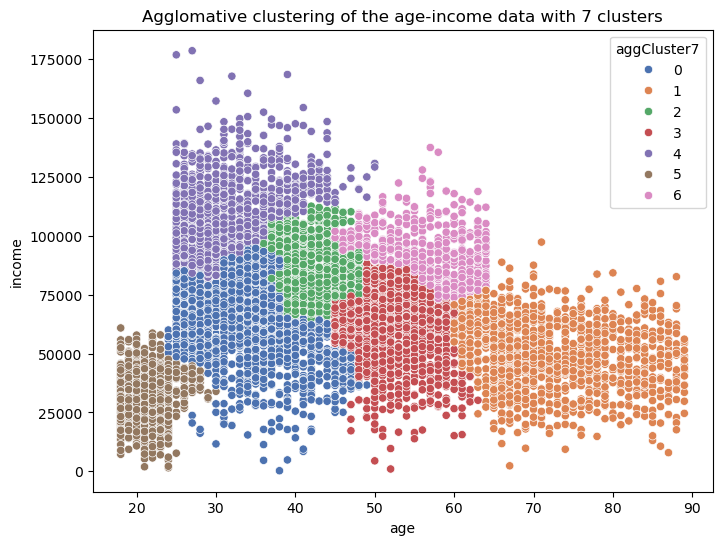

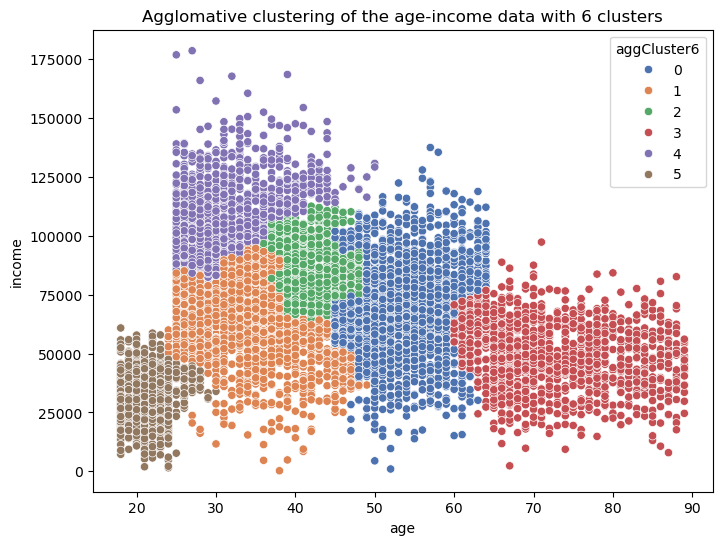

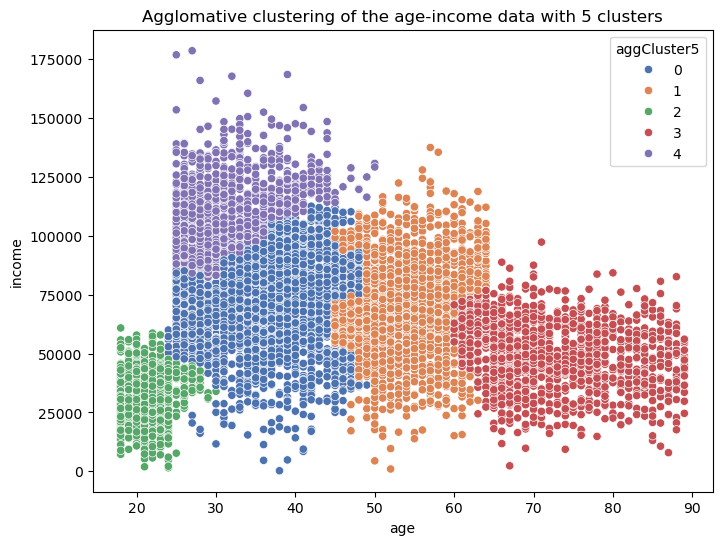

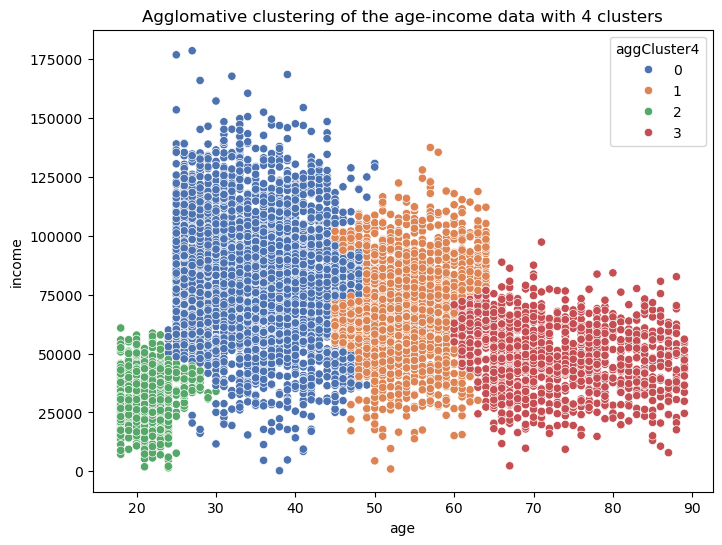

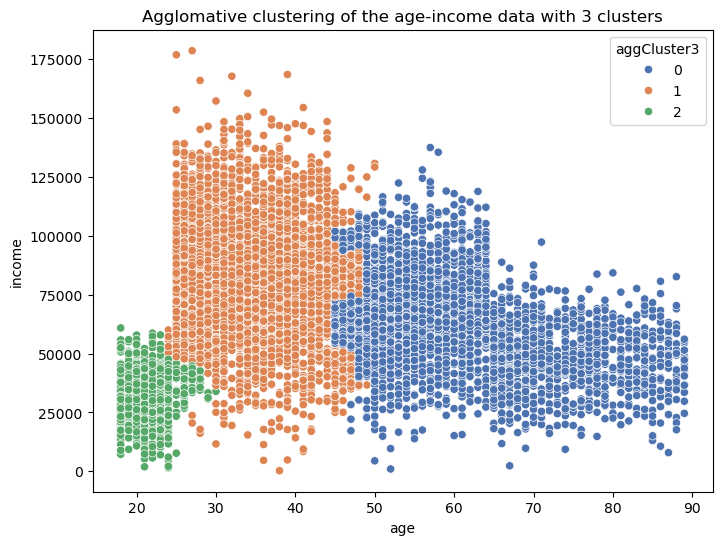

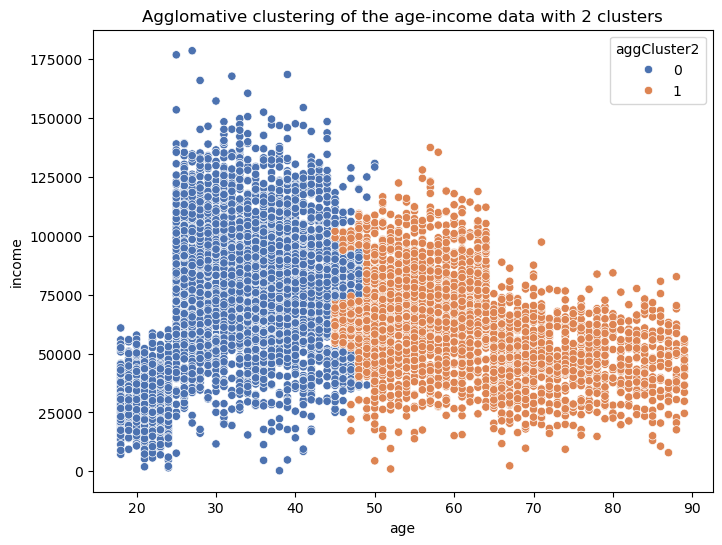

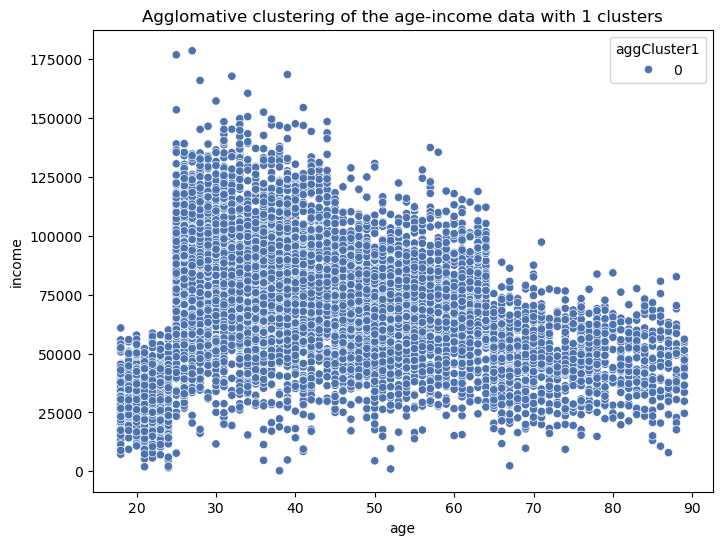

In [8]:
for cn in range(10, 0, -1):
    aggClustering(cn)

### Linkage

Note that we have not said anything about "linkage" or "Inter-Cluster Similarity". The default in `AgglomerativeClustering` is *Ward*, but it can easily be changed to *complete*, *average*, or *single*. Let us compare them for 7 clusters:

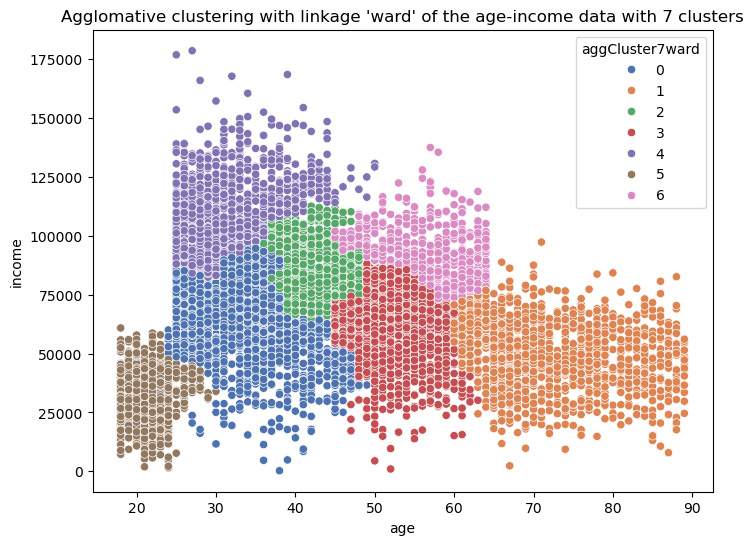

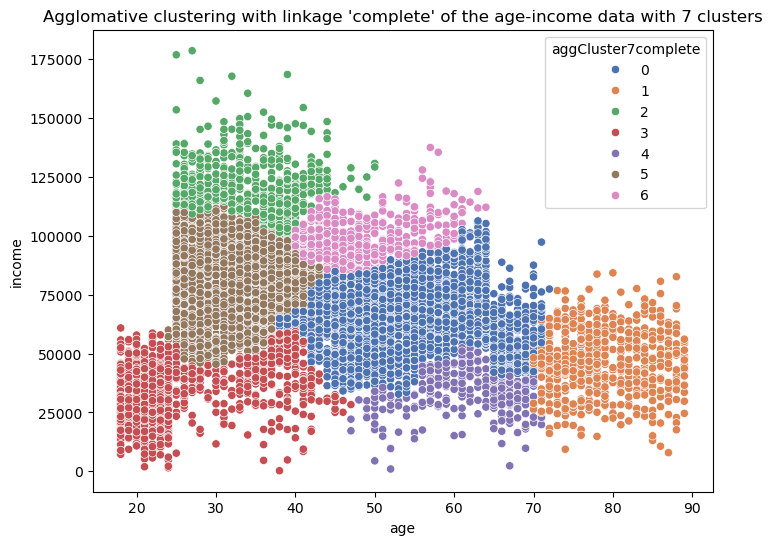

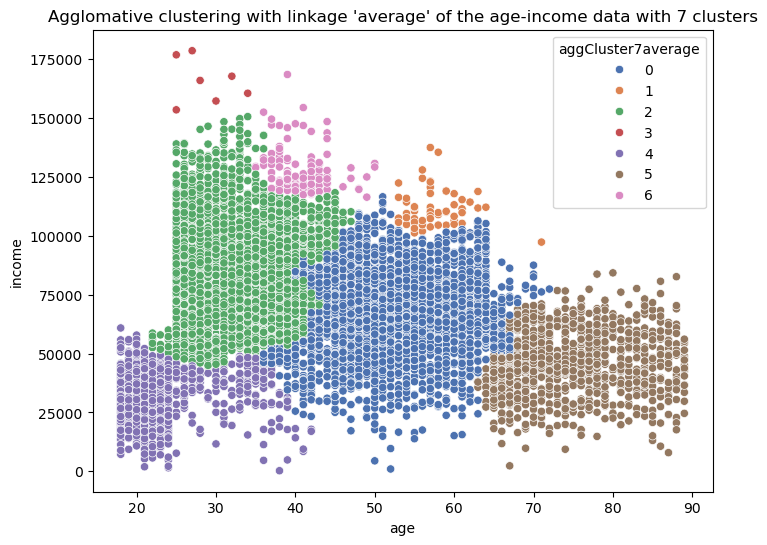

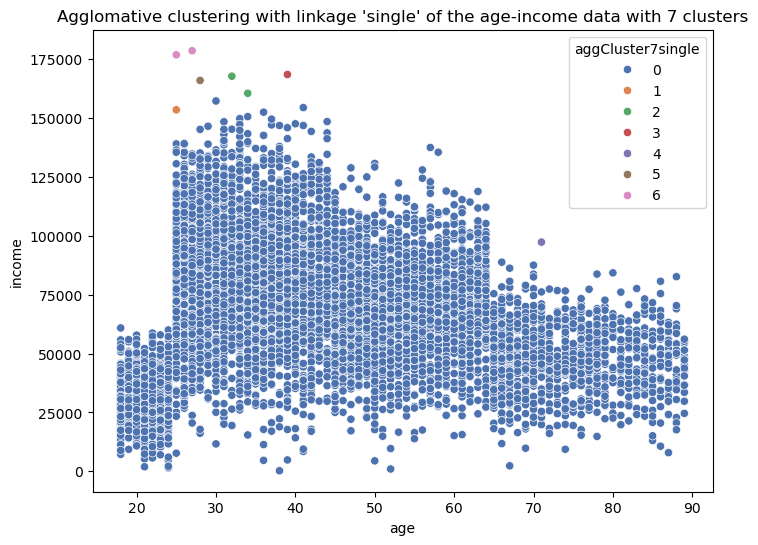

In [9]:
n=7

LinkageMethod = "ward"
agg = AgglomerativeClustering(n_clusters=n, linkage=LinkageMethod)
agg.fit(X_scaled_mm)
data["aggCluster{0}{1}".format(n, LinkageMethod)] = agg.labels_
plt.figure(figsize=(8, 6))
sns.scatterplot(data = data, x = "age", y = "income", hue = "aggCluster{0}{1}".format(n, LinkageMethod), palette="deep")
plt.title("Agglomative clustering with linkage '{1}' of the age-income data with {0} clusters".format(n, LinkageMethod))
plt.show()

LinkageMethod = "complete"
agg = AgglomerativeClustering(n_clusters=n, linkage=LinkageMethod)
agg.fit(X_scaled_mm)
data["aggCluster{0}{1}".format(n, LinkageMethod)] = agg.labels_
plt.figure(figsize=(8, 6))
sns.scatterplot(data = data, x = "age", y = "income", hue = "aggCluster{0}{1}".format(n, LinkageMethod), palette="deep")
plt.title("Agglomative clustering with linkage '{1}' of the age-income data with {0} clusters".format(n, LinkageMethod))
plt.show()

LinkageMethod = "average"
agg = AgglomerativeClustering(n_clusters=n, linkage=LinkageMethod)
agg.fit(X_scaled_mm)
data["aggCluster{0}{1}".format(n, LinkageMethod)] = agg.labels_
plt.figure(figsize=(8, 6))
sns.scatterplot(data = data, x = "age", y = "income", hue = "aggCluster{0}{1}".format(n, LinkageMethod), palette="deep")
plt.title("Agglomative clustering with linkage '{1}' of the age-income data with {0} clusters".format(n, LinkageMethod))
plt.show()

LinkageMethod = "single"
agg = AgglomerativeClustering(n_clusters=n, linkage=LinkageMethod)
agg.fit(X_scaled_mm)
data["aggCluster{0}{1}".format(n, LinkageMethod)] = agg.labels_
plt.figure(figsize=(8, 6))
sns.scatterplot(data = data, x = "age", y = "income", hue = "aggCluster{0}{1}".format(n, LinkageMethod), palette="deep")
plt.title("Agglomative clustering with linkage '{1}' of the age-income data with {0} clusters".format(n, LinkageMethod))
plt.show()

### Dendrogram
 
Let us now see show how to generate Dendrograms, and how to decide the number of clusters from a Dendrogram. 

In the script below, we import the hierarchy class of the scipy.cluster library as shc. The hierarchy class has a dendrogram method which takes the value returned by the linkage method of the same class. The linkage method takes the dataset and the method to minimize distances as parameters. We use 'ward' as the method since it minimizes then variants of distances between the clusters.

In [10]:
import scipy.cluster.hierarchy as shc

Note that this takes a while to plot!

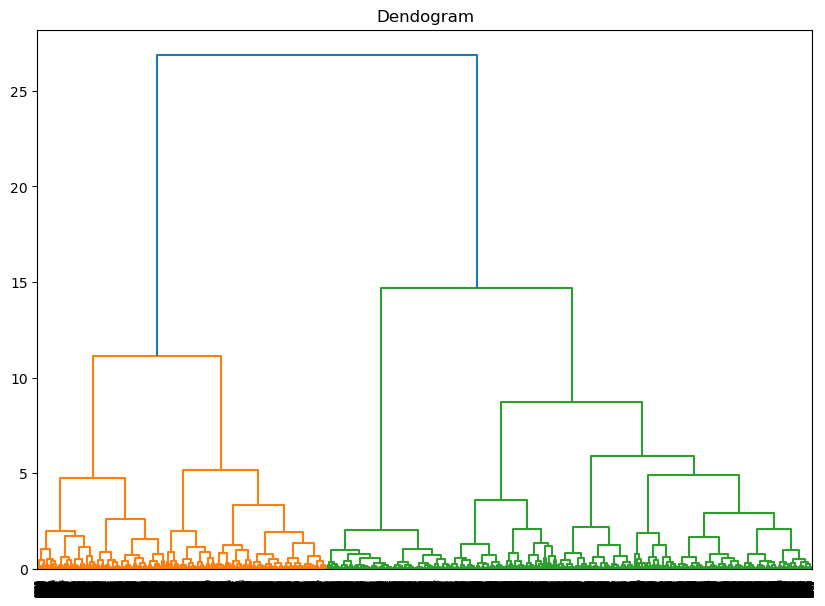

In [11]:
plt.figure(figsize=(10, 7))
plt.title("Dendogram")
dend = shc.dendrogram(shc.linkage(X_scaled_mm, method='ward'))
plt.show()

We can add a horizontal line to the above plot for particular y values in the following way:

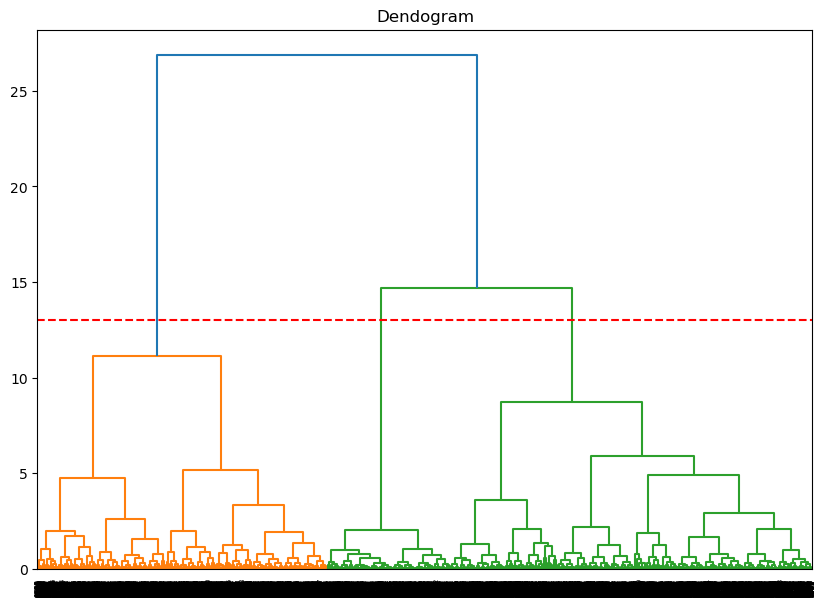

In [12]:
plt.figure(figsize=(10, 7))
plt.title("Dendogram")
dend = shc.dendrogram(shc.linkage(X_scaled_mm, method='ward'))

plt.axhline(y=13, color='r', linestyle='--')

plt.show()